## Classification Model

Loading data from 'extinction_data.xlsx'...
Data loaded successfully. Found 5301 data points.
Data split into 3975 training and 1326 testing samples.

Defining models and hyperparameter grids for tuning...

--- Tuning Logistic Regression ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Finished tuning Logistic Regression in 5.75 seconds.

--- Tuning Support Vector (SVC) ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Finished tuning Support Vector (SVC) in 5.62 seconds.

--- Tuning Random Forest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Finished tuning Random Forest in 5.30 seconds.

--- Tuning XGBoost ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\robys\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:48:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Finished tuning XGBoost in 1.07 seconds.

--- Tuning LightGBM ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Number of positive: 2481, number of negative: 1494
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 60
[LightGBM] [Info] Number of data points in the train set: 3975, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.624151 -> initscore=0.507205
[LightGBM] [Info] Start training from score 0.507205
Finished tuning LightGBM in 8.91 seconds.

--- Tuning CatBoost ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Finished tuning CatBoost in 14.15 seconds.


                 SURROGATE MODEL PERFORMANCE COMPARISON
                      Best F1 (CV)   Test F1  Test Accuracy  Test Precision  \
Model                                                                         
Ca

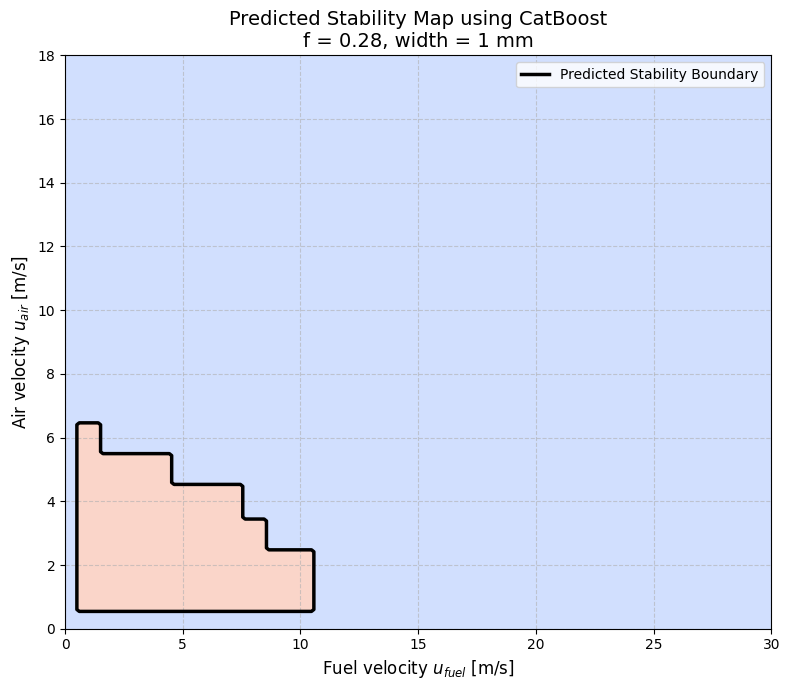

In [3]:
# ---------------------------------------------------------------------------
# COMPREHENSIVE ML SURROGATE MODEL COMPARISON SCRIPT
#
# Description:
# This script systematically trains, tunes, and compares multiple machine
# learning algorithms to find the best surrogate model for predicting
# counterflow flame stability from the Cantera simulation data.
#
# It then uses the best-performing model to predict and visualize the
# stability map for a specific, user-defined case.
#
# Steps:
# 1. Load the dataset from 'extinction_data.xlsx'.
# 2. Define a suite of algorithms (Logistic Regression, SVC, Random Forest,
#    XGBoost, LightGBM, CatBoost) and their hyperparameter grids.
# 3. Loop through each algorithm, performing hyperparameter tuning with
#    GridSearchCV and 5-fold cross-validation.
# 4. Evaluate each tuned model on a held-out test set.
# 5. Display a summary table comparing the performance of all models.
# 6. Select the best model and generate a prediction plot for a new case.
# ---------------------------------------------------------------------------

import time
from pathlib import Path

# Core libraries for data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn for ML workflow, models, and metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Advanced Boosting Libraries
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# ---------------------------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------------------------

# --- INPUT & OUTPUT ---
DATA_FILE = Path("extinction_data.xlsx")
OUTPUT_PLOT_FILE = Path("prediction_map_best_model.png")

# --- MODEL FEATURES AND TARGET ---
FEATURES = ["f_crack", "u_fuel", "u_air", "width"]
TARGET = "stable"

# --- PREDICTION CASE ---
# We will use the best model to predict the stability map for these conditions
PRED_F_CRACK = 0.28
PRED_WIDTH = 0.01  # Using 0.01m (1cm) as it's within the training data range

# ---------------------------------------------------------------------------
# MAIN EXECUTION BLOCK
# ---------------------------------------------------------------------------

def main():
    """
    Main function to orchestrate the entire model training, comparison,
    and prediction workflow.
    """
    # --- 1. DATA LOADING AND PREPARATION ---
    print(f"Loading data from '{DATA_FILE}'...")
    if not DATA_FILE.exists():
        print(f"❌ Error: Data file not found. Please run the Cantera simulation script first.")
        return

    df = pd.read_excel(DATA_FILE)
    print(f"Data loaded successfully. Found {len(df)} data points.")

    X = df[FEATURES]
    y = df[TARGET]

    # Split data into training and testing sets (75% train, 25% test)
    # stratify=y ensures the proportion of stable/extinct points is the same
    # in both train and test sets, which is crucial for model evaluation.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    print(f"Data split into {len(X_train)} training and {len(X_test)} testing samples.")

    # --- 2. DEFINE MODELS AND HYPERPARAMETER GRIDS ---
    print("\nDefining models and hyperparameter grids for tuning...")

    # For models sensitive to feature scaling (Logistic Regression, SVC),
    # we need to scale the data. We'll do this within the training loop.
    scaler = StandardScaler()

    models_to_tune = [
        {
            'name': 'Logistic Regression',
            'estimator': LogisticRegression(random_state=42, max_iter=1000),
            'params': {
                'C': [0.1, 1.0, 10.0],
                'solver': ['liblinear', 'lbfgs']
            },
            'requires_scaling': True
        },
        {
            'name': 'Support Vector (SVC)',
            'estimator': SVC(random_state=42, probability=True),
            'params': {
                'C': [1, 10, 50],
                'gamma': ['scale', 'auto'],
                'kernel': ['rbf']
            },
            'requires_scaling': True
        },
        {
            'name': 'Random Forest',
            'estimator': RandomForestClassifier(random_state=42),
            'params': {
                'n_estimators': [100, 150],
                'max_depth': [10, 20, None],
                'min_samples_leaf': [1, 2]
            },
            'requires_scaling': False
        },
        {
            'name': 'XGBoost',
            'estimator': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
            'params': {
                'n_estimators': [100, 200],
                'learning_rate': [0.05, 0.1],
                'max_depth': [5, 7]
            },
            'requires_scaling': False
        },
        {
            'name': 'LightGBM',
            'estimator': lgb.LGBMClassifier(random_state=42),
            'params': {
                'n_estimators': [100, 200],
                'learning_rate': [0.05, 0.1],
                'num_leaves': [31, 50]
            },
            'requires_scaling': False
        },
        {
            'name': 'CatBoost',
            'estimator': cb.CatBoostClassifier(random_state=42, verbose=0),
            'params': {
                'iterations': [200, 300],
                'learning_rate': [0.05, 0.1],
                'depth': [6, 8]
            },
            'requires_scaling': False
        },
    ]

    # --- 3. & 4. TRAIN, TUNE, AND EVALUATE MODELS ---
    results = []
    trained_models = {}
    
    for model_info in models_to_tune:
        name = model_info['name']
        estimator = model_info['estimator']
        params = model_info['params']
        
        print(f"\n--- Tuning {name} ---")
        start_time = time.time()

        # Scale data if required by the model
        X_train_processed = scaler.fit_transform(X_train) if model_info['requires_scaling'] else X_train
        X_test_processed = scaler.transform(X_test) if model_info['requires_scaling'] else X_test
        
        # Setup GridSearchCV
        grid_search = GridSearchCV(
            estimator=estimator,
            param_grid=params,
            cv=5,
            n_jobs=-1,
            verbose=1,
            scoring='f1' # Optimize for F1-score, a good balance for this problem
        )
        
        # Train the model
        grid_search.fit(X_train_processed, y_train)
        
        # Store the best model
        best_model = grid_search.best_estimator_
        trained_models[name] = best_model
        
        # Evaluate on the test set
        y_pred = best_model.predict(X_test_processed)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        end_time = time.time()
        duration = end_time - start_time
        
        # Store results
        results.append({
            'Model': name,
            'Best F1 (CV)': grid_search.best_score_,
            'Test F1': f1,
            'Test Accuracy': accuracy,
            'Test Precision': precision,
            'Test Recall': recall,
            'Tuning Time (s)': duration
        })
        
        print(f"Finished tuning {name} in {duration:.2f} seconds.")

    # --- 5. COMPARE MODELS ---
    results_df = pd.DataFrame(results)
    results_df.sort_values(by='Test F1', ascending=False, inplace=True)
    results_df = results_df.set_index('Model')
    
    print("\n\n" + "="*80)
    print("                 SURROGATE MODEL PERFORMANCE COMPARISON")
    print("="*80)
    print(results_df)
    print("="*80)

    # --- 6. PREDICT WITH BEST MODEL ---
    best_model_name = results_df.index[0]
    best_model = trained_models[best_model_name]
    print(f"\n🏆 Best performing model is: '{best_model_name}'")
    print(f"Proceeding to generate prediction plot for this model...")

    # Create a high-resolution grid for plotting
    u_fuel_range = np.linspace(X.u_fuel.min(), X.u_fuel.max(), 150)
    u_air_range = np.linspace(X.u_air.min(), X.u_air.max(), 150)
    xx, yy = np.meshgrid(u_fuel_range, u_air_range)
    
    # Create the feature matrix for every point in the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_df = pd.DataFrame(grid_points, columns=['u_fuel', 'u_air'])
    grid_df['f_crack'] = PRED_F_CRACK
    grid_df['width'] = PRED_WIDTH
    grid_df = grid_df[FEATURES] # Ensure correct column order

    # Preprocess grid data if the best model requires it
    if any(m['name'] == best_model_name and m['requires_scaling'] for m in models_to_tune):
        print("Scaling prediction data for the best model...")
        grid_df_processed = scaler.transform(grid_df)
    else:
        grid_df_processed = grid_df
        
    # Predict stability for the entire grid
    Z = best_model.predict(grid_df_processed)
    Z = Z.reshape(xx.shape)

    # Generate the plot
    plt.figure(figsize=(8, 7))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm, levels=[-0.5, 0.5, 1.5])
    contour_line = plt.contour(xx, yy, Z, colors='black', linewidths=2.5, levels=[0.5])
    
    plt.xlabel("Fuel velocity $u_{fuel}$ [m/s]", fontsize=12)
    plt.ylabel("Air velocity $u_{air}$ [m/s]", fontsize=12)
    plt.title(
        f"Predicted Stability Map using {best_model_name}\n"
        f"f = {PRED_F_CRACK:.2f}, width = {PRED_WIDTH*100:.0f} mm",
        fontsize=14
    )
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Create a custom legend entry for the stability boundary
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color='black', lw=2.5, label='Predicted Stability Boundary')]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    # The plot is now shown on screen but not saved to a file.
    # plt.savefig(OUTPUT_PLOT_FILE, dpi=300)
    # print(f"\n✅ Prediction plot successfully saved to '{OUTPUT_PLOT_FILE.resolve()}'")
    plt.show()


if __name__ == "__main__":
    main()

